# Phân tích Thống kê Insight từ Kết quả PrefixSpan (Bản nâng cấp)
Notebook này phân tích các quy luật lây lan kẹt xe (Domino Jams) và ánh xạ chúng ngược lại các Trạm xe buýt thực tế để đưa ra các insight có thể hành động được (Actionable Insights).

In [8]:
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from prefixspan import PrefixSpan

# Thêm đường dẫn project vào sys.path để import helpers
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from pipelines.prefix_span import sequential_mining, translate_zones_to_stations, process_prefixspan_coords

sns.set_theme(style="whitegrid")

## 1. Load Dữ liệu
Dữ liệu bao gồm các điểm kẹt xe (`black_spot.parquet`) và thông tin trạm xe buýt (`bus_station_data.json`) để ánh xạ địa danh.

In [9]:
jam_path = os.path.join(PROJECT_ROOT, 'data', 'black_spot.parquet')
station_path = os.path.join(PROJECT_ROOT, 'data', '2_silver', 'bus_station_data.json')

if not os.path.exists(jam_path) or not os.path.exists(station_path):
    print("Vui lòng đảm bảo các file dữ liệu tồn tại.")
else:
    jam_df = pd.read_parquet(jam_path)
    with open(station_path, 'r', encoding='utf-8') as f:
        station_data = json.load(f)
    station_df = pd.DataFrame(station_data)
    
    print(f"Đã load {len(jam_df)} điểm kẹt và {len(station_df)} trạm xe buýt.")


Đã load 933436 điểm kẹt và 1644 trạm xe buýt.


## 2. Tìm kiếm các Frequent Patterns (Domino Jams)
Chúng ta sẽ chạy PrefixSpan và sau đó "dịch" các tọa độ Zone sang Tên trạm gần nhất.

In [10]:
# 1. Chạy thuật toán mining cơ bản
pattern_df = sequential_mining(jam_df, min_support=20)

# 2. Ánh xạ sang tên trạm (Sử dụng helper từ dự án)
pattern_df = translate_zones_to_stations(pattern_df, station_df)

print(f"Tìm thấy {len(pattern_df)} chuỗi lây lan kẹt xe.")
display(pattern_df[['Readable_Pattern', 'Frequency']].head(10))

[2026-04-12 19:42:56] INFO - prefixspan_pipeline: Giữ lại 1142 zone phổ biến (loại 1439 zone hiếm).
[2026-04-12 19:42:56] INFO - prefixspan_pipeline: PrefixSpan input: 1993 chuỗi, min_support=20, maxlen=5
[2026-04-12 19:42:56] INFO - prefixspan_pipeline: PrefixSpan output: 419 patterns tìm thấy.
[2026-04-12 19:42:56] INFO - prefixspan_pipeline: Đã ánh xạ 152 zone → tên trạm.
Tìm thấy 107 chuỗi lây lan kẹt xe.


,Readable_Pattern,Frequency
270,[Siêu thị Coopmart] ➡️ [Đường 30],39
266,[Siêu thị Coopmart] ➡️ [Đường 30],39
396,[Siêu thị Văn Lang] ➡️ [Giáo xứ Mân Côi],37
58,[Ngã tư Hóc Môn] ➡️ [cầu vượt An Sương],37
108,[Công ty Fujifilm] ➡️ [Ngã tư Hóc Môn],36
271,[Siêu thị Coopmart] ➡️ [Đường 30],35
65,[Ngã tư Hóc Môn] ➡️ [Chùa Linh Sơn],33
32,[Bến xe An Sương] ➡️ [cầu vượt An Sương],33
46,[Ngã 3 Hồng Châu] ➡️ [Ngã tư Hóc Môn],33
82,[cầu vượt An Sương] ➡️ [Công ty Fujifilm],33


## 3. Thống kê Insider: Top trạm "Phát tán" kẹt xe (Root Causes)
Chúng ta sẽ đếm xem trạm nào thường xuyên nằm ở **vị trí bắt đầu** của chuỗi Domino nhất.

C:\Users\nguye\AppData\Local\Temp\ipykernel_7136\606872716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_stats.head(10), x='Frequency', y='Start_Station', palette='Reds_r')


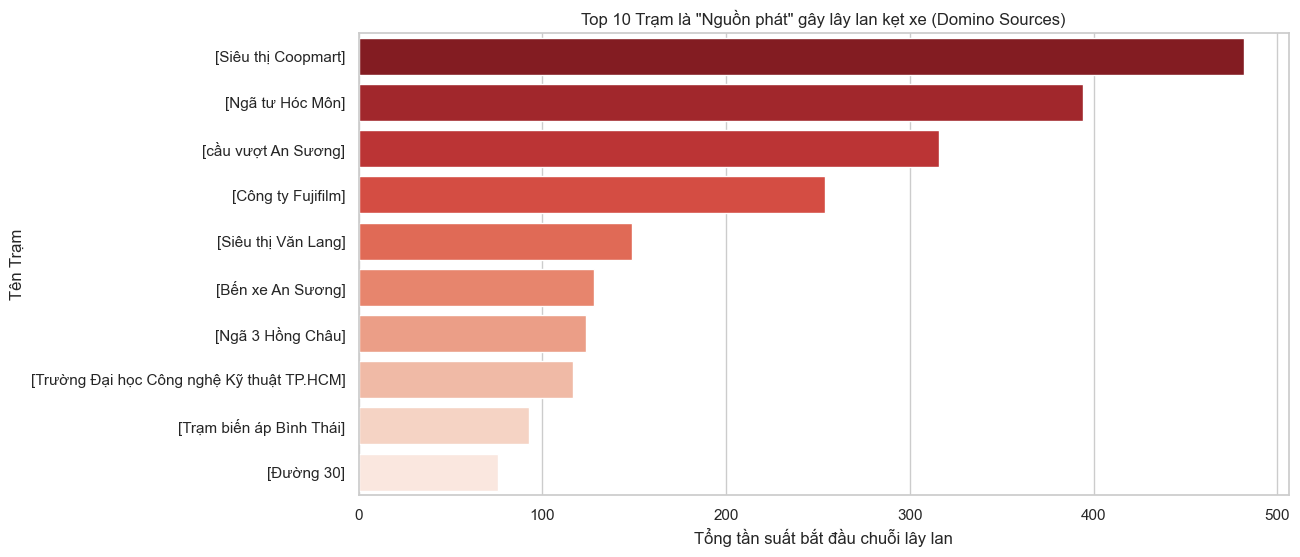

In [11]:
# Tách lấy trạm đầu tiên trong cột Readable_Pattern
pattern_df['Start_Station'] = pattern_df['Readable_Pattern'].apply(lambda x: x.split(' ➡️ ')[0])
pattern_df['End_Station'] = pattern_df['Readable_Pattern'].apply(lambda x: x.split(' ➡️ ')[-1])

source_stats = pattern_df.groupby('Start_Station')['Frequency'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=source_stats.head(10), x='Frequency', y='Start_Station', palette='Reds_r')
plt.title('Top 10 Trạm là "Nguồn phát" gây lây lan kẹt xe (Domino Sources)')
plt.xlabel('Tổng tần suất bắt đầu chuỗi lây lan')
plt.ylabel('Tên Trạm')
plt.show()

## 4. Thống kê Insider: Top trạm "Hứng Chịu" kẹt xe (Bottlenecks)
Đây là những trạm thường xuyên là **vị trí kết thúc** của chuỗi Domino.

C:\Users\nguye\AppData\Local\Temp\ipykernel_7136\1874115025.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sink_stats.head(10), x='Frequency', y='End_Station', palette='Blues_r')


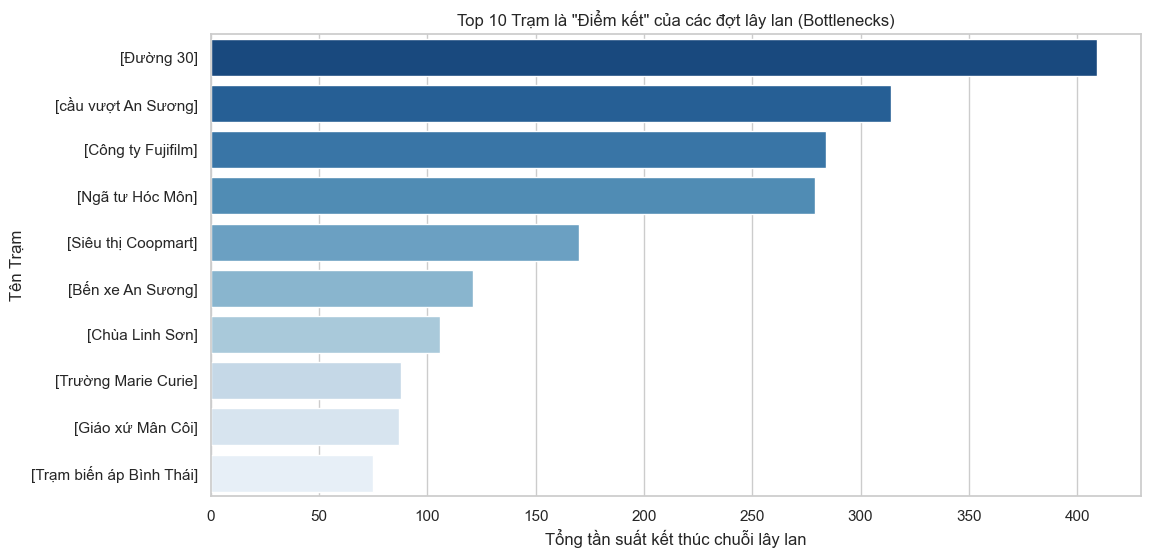

In [12]:
sink_stats = pattern_df.groupby('End_Station')['Frequency'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=sink_stats.head(10), x='Frequency', y='End_Station', palette='Blues_r')
plt.title('Top 10 Trạm là "Điểm kết" của các đợt lây lan (Bottlenecks)')
plt.xlabel('Tổng tần suất kết thúc chuỗi lây lan')
plt.ylabel('Tên Trạm')
plt.show()

## 5. Ma trận Xác suất Chuyển trạng thái (Transition Probability)
Nếu một chiếc xe buýt gặp kẹt xe tại Trạm A, xác suất nó sẽ tiếp tục kẹt ở Trạm B kế tiếp là bao nhiêu?

In [13]:
transitions = []
for _, row in pattern_df.iterrows():
    stations = row['Readable_Pattern'].split(' ➡️ ')
    freq = row['Frequency']
    for i in range(len(stations) - 1):
        transitions.append({'From': stations[i], 'To': stations[i+1], 'Freq': freq})

trans_df = pd.DataFrame(transitions).groupby(['From', 'To'])['Freq'].sum().reset_index()
total_from = trans_df.groupby('From')['Freq'].sum().rename('Total_Freq')
trans_df = trans_df.merge(total_from, on='From')
trans_df['Prob'] = (trans_df['Freq'] / trans_df['Total_Freq'] * 100).round(2)

print("Top 10 'Cặp bài trùng' lây lan kẹt xe có xác suất cao nhất:")
display(trans_df.sort_values(['Prob', 'Freq'], ascending=False).head(10))

Top 10 'Cặp bài trùng' lây lan kẹt xe có xác suất cao nhất:


,From,To,Freq,Total_Freq,Prob
54,[Đường 30],[Siêu thị Coopmart],76,76,100.0
22,[Nguyễn Thị Ai],[Công ty Fujifilm],53,53,100.0
4,[Bệnh viện Phạm Ngọc Thạch],[Nguyễn Thị Minh Khai],27,27,100.0
5,[Chùa Linh Sơn],[cầu vượt An Sương],25,25,100.0
41,[Trường Marie Curie],[Khách sạn Sofitel],24,24,100.0
37,[Siêu thị Nguyễn Kim],[Siêu thị Coopmart],23,23,100.0
0,[Bình Long],[Trường Marie Curie],22,22,100.0
26,[Ngã ba Hồng Đào],[Trường Marie Curie],22,22,100.0
6,[Chùa Vĩnh Phước],[Bến xe An Sương],20,20,100.0
7,[Chợ Hàng Xanh],[Cầu Sài Gòn],20,20,100.0


## 6. Kết luận và Kiến nghị
Dựa trên các phân tích thống kê trên, chúng ta rút ra các insight quan trọng:

1. **Xác định Root Cause**: Các trạm trong biểu đồ **"Nguồn phát"** (Mục 3) cần được ưu tiên bố trí lực lượng điều tiết hoặc giải tỏa hành lang ngay khi có tín hiệu kẹt xe nhẹ, vì chúng có xác suất cao gây ra hiệu ứng domino cho toàn tuyến.
2. **Hành lang trọng điểm**: Các cặp trạm trong **Ma trận chuyển trạng thái** (Mục 5) với xác suất > 50% cho thấy sự liên kết cực kỳ chặt chẽ về mặt giao thông. Nếu kẹt ở trạm A, gần như chắc chắn xe sẽ kẹt ở trạm B.
3. **Tối ưu hóa Điều độ**: Dispatcher có thể sử dụng các con số xác suất này để ra quyết định "cắt chuyến" hoặc "quay đầu" sớm trước khi xe buýt đi vào vùng lây lan diện rộng.